<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/lstm_optimizations/LSTM_Ridge_RandomSearch_add_1_lstm_1_hidden.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ================== IMPORTS ==================
import os
import random
import itertools
from datetime import timedelta, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# ================== CONFIG / CONSTANTS ==================
# Suppress TF logs for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Path to Excel file
INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'

# Train/test split settings
TEST_SET_DAYS = 60      # last 60 days reserved for test
VAL_DAYS = 90           # validation fold length
N_SPLITS = 2            # number of CV folds
N_TIMESTEPS = 7         # LSTM sequence window
MAPE_EPSILON = 1e-6     # avoid divide-by-zero in MAPE

# Target columns (meal periods)
TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']

# Feature engineering settings
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

# LSTM training settings
LSTM_EPOCHS = 50
LSTM_BATCH_SIZE = 32

# Search spaces
SEARCH_SPACE_LSTM_LR = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
SEARCH_SPACE_LSTM_UNITS = [32, 64, 128, 256]
SEARCH_SPACE_RIDGE_ALPHA = [0.1, 1.0, 10.0, 100.0]

In [10]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    """
    Add lag and rolling features for each target column.
    Shift ensures only past values are used (no leakage).
    """
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)

def create_sequences(data, target, n_timesteps):
    """
    Convert tabular data into sequences for LSTM.
    Each sample uses n_timesteps of history to predict the next target.
    """
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        X.append(data[i:(i + n_timesteps), :])
        y.append(target[i + n_timesteps])
    return np.array(X), np.array(y)

def smape(y_true, y_pred, eps=1e-6):
    numer = np.abs(y_pred - y_true)
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(min=eps)
    return np.mean(2.0 * numer / denom) * 100.0

def mae_np(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def build_lstm_hybrid_model(input_shape_lstm, lr, units):
    """
    Build LSTM + Dense hybrid model with Adam optimizer.
    Includes dropout for regularization.
    """
    lstm_input = Input(shape=input_shape_lstm, name='lstm_input')
    lstm_out1 = LSTM(units, return_sequences=True, name='lstm_1')(lstm_input)
    lstm_out1 = Dropout(0.2)(lstm_out1)
    lstm_out2 = LSTM(units, return_sequences=False, name='lstm_2')(lstm_out1)
    lstm_out2 = Dropout(0.2)(lstm_out2)

    dense_hidden1 = Dense(max(units // 2, 8), activation='relu', name='dense_hidden_1')(lstm_out2)
    dense_hidden2 = Dense(max(units // 4, 8), activation='relu', name='dense_hidden_2')(dense_hidden1)


    output = Dense(1, activation='linear', name='output')(dense_hidden2)

    model = Model(inputs=lstm_input, outputs=output)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    # IMPORTANT: Add MAE for TensorBoard accuracy-like metric
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

def dynamic_weights(y_true, y_pred_a, y_pred_b):
    """
    Compute ensemble weights based on RMSE of each model.
    Lower RMSE → higher weight.
    """
    rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_a))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_pred_b))
    total = rmse_a + rmse_b if (rmse_a + rmse_b) > 0 else 1.0
    w_a = 1 - (rmse_a / total)
    w_b = 1 - w_a
    return w_a, w_b

# ================== PLOTTING ==================
def plot_test_results(test_df, center_name, meal_period):
    """Plot actual vs predicted revenue for test set."""
    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def plot_residuals_over_time(residuals_df, center_name, meal_period):
    """Plot residuals (Actual - Predicted) over time for test set."""
    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()

def save_static_plot(history, center_name, meal_period):
    """
    Save training/validation Loss and MAE curves as PNG files to github_results.
    """
    output_dir = 'github_results'
    os.makedirs(output_dir, exist_ok=True)
    safe_name = center_name.replace(" ", "_")

    plt.figure(figsize=(10, 5))
    plt.plot(history.history.get('loss', []), label='Train Loss (MSE)', color='#1f77b4', lw=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss (MSE)', color='#ff7f0e', lw=2)
    if 'mae' in history.history:
        plt.plot(history.history['mae'], label='Train MAE', color='#2ca02c', lw=2)
    if 'val_mae' in history.history:
        plt.plot(history.history['val_mae'], label='Val MAE', color='#d62728', lw=2)

    plt.title(f'Training Curves: {center_name} - {meal_period}')
    plt.xlabel('Epochs'); plt.ylabel('Metric Value')
    plt.legend(loc='upper right'); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{safe_name}_{meal_period}_metrics.png")
    plt.close()


In [11]:
# ================== CV SCORING ==================
def score_ensemble_lstm_and_weights(params, X_train_full, Y_train_full, tscv,
                                    raw_target_col, numeric_features, categorical_features):
    """
    CV scoring for (lr, units, alpha) on hybrid ensemble.
    Returns avg_rmse across folds, avg_w_lstm, avg_w_ridge.
    Ensemble weights are computed per fold on validation only.
    """
    lr, units, alpha = params
    fold_rmses, fold_w_lstm, fold_w_ridge = [], [], []

    for train_idx, val_idx in tscv.split(X_train_full):
        # Split train/val
        X_train_cv_raw, X_val_raw = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        Y_train_cv = Y_train_full.iloc[train_idx][raw_target_col]
        Y_val = Y_train_full.iloc[val_idx][raw_target_col]

        # Scale numeric features (fit on train only)
        scaler = StandardScaler()
        X_train_num_scaled = scaler.fit_transform(X_train_cv_raw[numeric_features])
        X_val_num_scaled = scaler.transform(X_val_raw[numeric_features])

        # Combine numeric + categorical
        X_train_cv_scaled = pd.concat(
            [pd.DataFrame(X_train_num_scaled, columns=numeric_features, index=X_train_cv_raw.index),
             X_train_cv_raw[categorical_features]], axis=1)
        X_val_scaled = pd.concat(
            [pd.DataFrame(X_val_num_scaled, columns=numeric_features, index=X_val_raw.index),
             X_val_raw[categorical_features]], axis=1)

        # Sequence creation
        X_seq_train, Y_seq_train = create_sequences(X_train_cv_scaled.values, Y_train_cv.values, N_TIMESTEPS)
        X_seq_val, Y_seq_val = create_sequences(X_val_scaled.values, Y_val.values, N_TIMESTEPS)
        if len(X_seq_train) == 0 or len(X_seq_val) == 0:
            continue

        # Ridge data aligned with sequences
        X_ridge_train = X_train_cv_scaled.iloc[N_TIMESTEPS:]
        X_ridge_val = X_val_scaled.iloc[N_TIMESTEPS:]
        Y_ridge_train = Y_train_cv.iloc[N_TIMESTEPS:]

        # Train LSTM
        tf.keras.backend.clear_session()
        lstm_model = build_lstm_hybrid_model((N_TIMESTEPS, X_seq_train.shape[2]), lr, units)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        lstm_model.fit(X_seq_train, Y_seq_train,
                       validation_data=(X_seq_val, Y_seq_val),
                       epochs=LSTM_EPOCHS, batch_size=LSTM_BATCH_SIZE,
                       callbacks=[es_callback], verbose=0)
        y_pred_lstm = lstm_model.predict(X_seq_val, verbose=0).flatten()

        # Train Ridge
        ridge_model = Ridge(alpha=alpha).fit(X_ridge_train, Y_ridge_train)
        y_pred_ridge = ridge_model.predict(X_ridge_val).flatten()

        # Align lengths
        min_len = min(len(Y_seq_val), len(y_pred_lstm), len(y_pred_ridge))
        if min_len == 0:
            continue

        Y_seq_val_trunc = Y_seq_val[:min_len]
        y_pred_lstm_trunc = y_pred_lstm[:min_len]
        y_pred_ridge_trunc = y_pred_ridge[:min_len]

        # Compute ensemble weights on validation only (no leakage)
        w_lstm, w_ridge = dynamic_weights(Y_seq_val_trunc, y_pred_lstm_trunc, y_pred_ridge_trunc)
        y_pred_val_ens = (w_lstm * y_pred_lstm_trunc) + (w_ridge * y_pred_ridge_trunc)

        # Fold RMSE
        rmse = np.sqrt(mean_squared_error(Y_seq_val_trunc, y_pred_val_ens))
        fold_rmses.append(rmse)
        fold_w_lstm.append(w_lstm)
        fold_w_ridge.append(w_ridge)

    # Return averages across folds
    return (np.mean(fold_rmses) if fold_rmses else float('inf'),
            float(np.mean(fold_w_lstm)) if fold_w_lstm else 0.5,
            float(np.mean(fold_w_ridge)) if fold_w_ridge else 0.5)

In [12]:
# ================== RANDOM SEARCH ==================
def random_search_tune(X_train_full, Y_train_full, tscv, raw_target_col,
                       numeric_features, categorical_features,
                       lr_list, units_list, alpha_list, n_trials=12):
    """
    Randomly sample n_trials combinations from discrete lists.
    Returns best (avg_cv_rmse, avg_w_lstm, avg_w_ridge, best_params).
    """
    grid = list(itertools.product(lr_list, units_list, alpha_list))
    combos = random.sample(grid, min(n_trials, len(grid)))

    best_rmse = float('inf')
    best_params = None
    best_w = (0.5, 0.5)

    for params in combos:
        avg_rmse, w_lstm, w_ridge = score_ensemble_lstm_and_weights(
            params=params,
            X_train_full=X_train_full,
            Y_train_full=Y_train_full,
            tscv=tscv,
            raw_target_col=raw_target_col,
            numeric_features=numeric_features,
            categorical_features=categorical_features
        )
        if avg_rmse < best_rmse:
            best_rmse = avg_rmse
            best_params = params
            best_w = (w_lstm, w_ridge)

    return best_rmse, best_w[0], best_w[1], best_params

def get_small_ranges_for_period(meal_period):
    """
    Optional: tighten ranges based on observed winners.
    Falls back to global lists if not matched.
    """
    if meal_period == 'BreakFast':
        return [1e-3, 5e-3, 1e-2], [64], [10.0]
    if meal_period == 'Dinner':
        return [1e-4, 5e-4, 1e-3], [128, 64], [1.0, 10.0]
    if meal_period == 'Lunch':
        return [5e-4, 1e-3, 2e-3], [64, 128], [10.0, 100.0]
    return SEARCH_SPACE_LSTM_LR, SEARCH_SPACE_LSTM_UNITS, SEARCH_SPACE_RIDGE_ALPHA

In [13]:
# ================== MAIN TRAINING FUNCTION ==================
def train_and_plot_for_center(df_center, center_name):
    """
    Train hybrid LSTM + Ridge model for one revenue center.
    Logs to TensorBoard and saves static training curves.
    Also saves a summary CSV of optimal params and CV metrics.
    """
    # Feature engineering
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # Train/test split by date
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # TimeSeriesSplit for CV tuning
    tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=VAL_DAYS, gap=N_TIMESTEPS)

    # Separate features
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train_full = df_train_full[feature_cols]
    Y_train_full = df_train_full[TARGET_RAW_COLS]

    summary_rows = []

    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace('Revenue_By_', '')
        lr_list, units_list, alpha_list = get_small_ranges_for_period(meal_period)

        # 1. Hyperparameter Tuning (CV)
        best_cv_rmse, w_lstm_cv, w_ridge_cv, best_params = random_search_tune(
            X_train_full=X_train_full, Y_train_full=Y_train_full, tscv=tscv,
            raw_target_col=raw_target_col, numeric_features=numeric_features,
            categorical_features=categorical_features, lr_list=lr_list,
            units_list=units_list, alpha_list=alpha_list, n_trials=12
        )
        best_lr, best_units, best_alpha = best_params
        print(f"✅ Optimal Params for {center_name} - {meal_period}: "
              f"LR={best_lr}, Units={best_units}, Alpha={best_alpha} | "
              f"CV RMSE={best_cv_rmse:.2f}, Weights(LSTM={w_lstm_cv:.2f}, Ridge={w_ridge_cv:.2f})")

        # 2. Prepare Data for Final Training
        final_scaler = StandardScaler()
        X_train_full_scaled = pd.DataFrame(
            final_scaler.fit_transform(X_train_full[numeric_features]),
            columns=numeric_features, index=X_train_full.index
        )
        X_train_final = pd.concat([X_train_full_scaled, df_train_full[categorical_features]], axis=1)
        Y_train_target = Y_train_full[raw_target_col].values

        # Create Sequences and split for training curves
        X_seq_total, Y_seq_total = create_sequences(X_train_final.values, Y_train_target, N_TIMESTEPS)
        split_idx = int(len(X_seq_total) * 0.8)
        X_train_tb, X_val_tb = X_seq_total[:split_idx], X_seq_total[split_idx:]
        y_train_tb, y_val_tb = Y_seq_total[:split_idx], Y_seq_total[split_idx:]

        # 3. TensorBoard Logging
        run_id = f"{center_name}_{meal_period}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
        log_dir = os.path.join("logs", "fit", run_id)
        tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
        es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

        # 4. Final Model Training
        tf.keras.backend.clear_session()
        final_lstm_model = build_lstm_hybrid_model((N_TIMESTEPS, X_train_tb.shape[2]), best_lr, best_units)

        print(f"📊 Training Final Model for {center_name} - {meal_period} "
              f"(LR={best_lr}, Units={best_units}, Alpha={best_alpha})")

        history = final_lstm_model.fit(
            X_train_tb, y_train_tb,
            validation_data=(X_val_tb, y_val_tb),
            epochs=LSTM_EPOCHS,
            batch_size=LSTM_BATCH_SIZE,
            callbacks=[tb_callback, es_callback],
            verbose=0
        )

        # Save static training curves (Loss + MAE)
        save_static_plot(history, center_name, meal_period)

        # Ridge Training (on full set aligned with sequences)
        X_ridge_train_final = X_train_final.iloc[N_TIMESTEPS:]
        Y_ridge_train_final = Y_train_full[raw_target_col].iloc[N_TIMESTEPS:]
        final_ridge_model = Ridge(alpha=best_alpha).fit(X_ridge_train_final, Y_ridge_train_final)

        # 5. Test Evaluation
        X_test_scaled = pd.DataFrame(
            final_scaler.transform(df_test_full[numeric_features]),
            columns=numeric_features, index=df_test_full.index
        )
        X_test_final = pd.concat([X_test_scaled, df_test_full[categorical_features]], axis=1).fillna(0)

        # Build LSTM test sequences by appending last N_TIMESTEPS from train features
        X_full_for_test = pd.concat([X_train_final.tail(N_TIMESTEPS), X_test_final], ignore_index=True).values
        X_seq_test, _ = create_sequences(X_full_for_test, np.zeros_like(X_full_for_test[:, 0]), N_TIMESTEPS)

        y_test_lstm = final_lstm_model.predict(X_seq_test, verbose=0).flatten()
        y_test_ridge = final_ridge_model.predict(X_test_final).flatten()

        min_len_test = min(len(df_test_full), len(y_test_lstm), len(y_test_ridge))
        y_test_ens = (w_lstm_cv * y_test_lstm[:min_len_test]) + (w_ridge_cv * y_test_ridge[:min_len_test])
        Y_test_actual = df_test_full[raw_target_col].values[:min_len_test]

        # Results Plotting
        plot_df = pd.DataFrame({
            'Date': df_test_full['Date'].iloc[:min_len_test],
            'Actual_Revenue': Y_test_actual,
            'Predicted_Revenue': y_test_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)

        # Add summary row
        summary_rows.append({
            'Center': center_name,
            'Meal_Period': meal_period,
            'Best_LR': best_lr,
            'Best_Units': best_units,
            'Best_Alpha': best_alpha,
            'CV_RMSE': round(best_cv_rmse, 4),
            'CV_W_LSTM': round(w_lstm_cv, 4),
            'CV_W_Ridge': round(w_ridge_cv, 4)
        })

    # Save summary CSV per center
    summary_df = pd.DataFrame(summary_rows)
    os.makedirs('github_results', exist_ok=True)
    summary_path = os.path.join('github_results', f"{center_name.replace(' ', '_')}_summary.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"📄 Saved summary: {summary_path}")
    print(summary_df)


================= Revenue Centre 1 =================
✅ Optimal Params for Revenue Centre 1 - BreakFast: LR=0.01, Units=64, Alpha=10.0 | CV RMSE=954.29, Weights(LSTM=0.47, Ridge=0.53)
📊 Training Final Model for Revenue Centre 1 - BreakFast (LR=0.01, Units=64, Alpha=10.0)


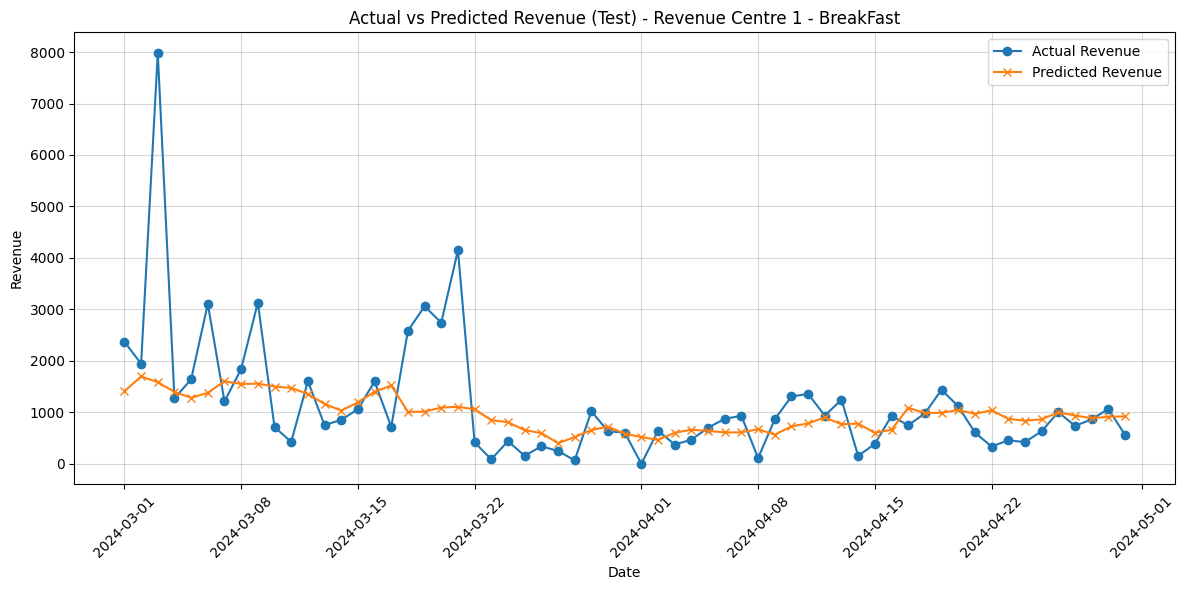

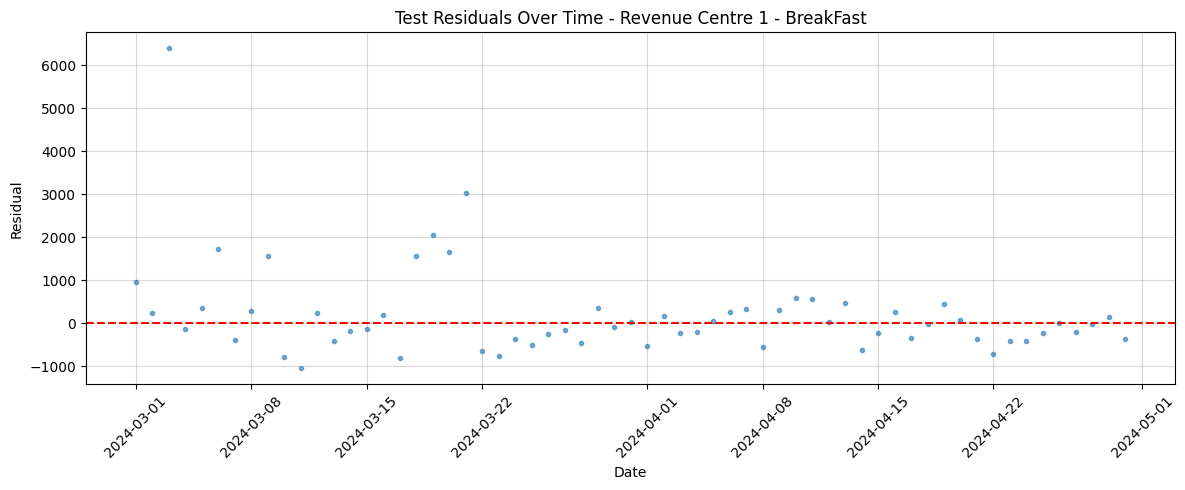

✅ Optimal Params for Revenue Centre 1 - Dinner: LR=0.0005, Units=128, Alpha=1.0 | CV RMSE=1562.36, Weights(LSTM=0.44, Ridge=0.56)
📊 Training Final Model for Revenue Centre 1 - Dinner (LR=0.0005, Units=128, Alpha=1.0)


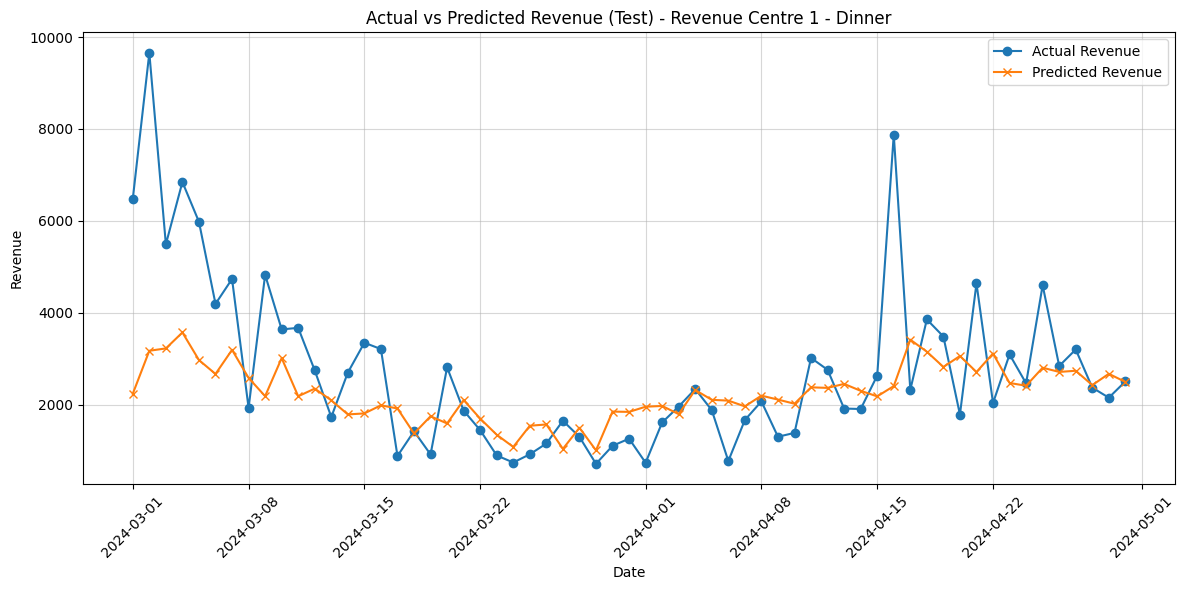

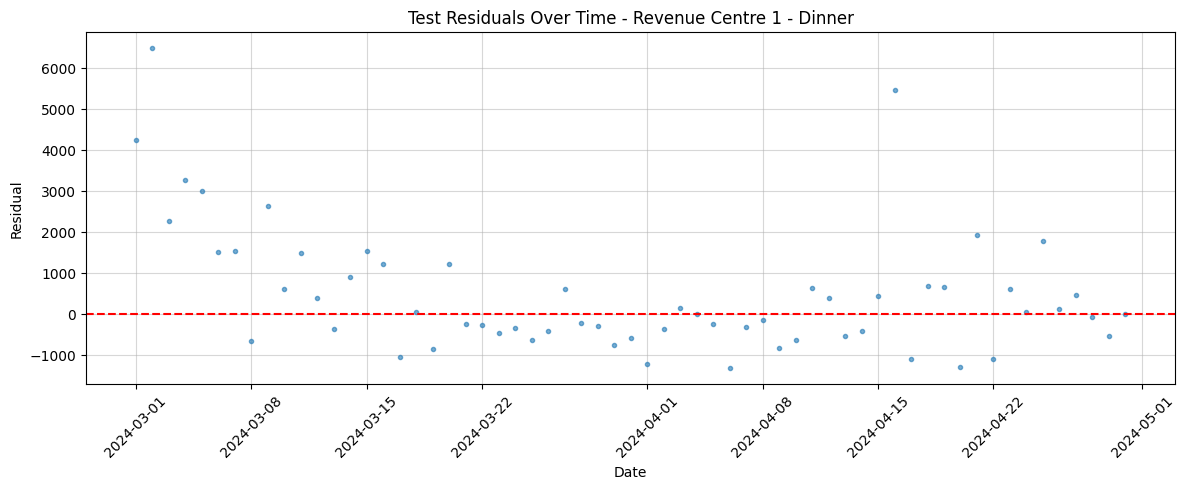

✅ Optimal Params for Revenue Centre 1 - Lunch: LR=0.002, Units=128, Alpha=10.0 | CV RMSE=789.76, Weights(LSTM=0.49, Ridge=0.51)
📊 Training Final Model for Revenue Centre 1 - Lunch (LR=0.002, Units=128, Alpha=10.0)


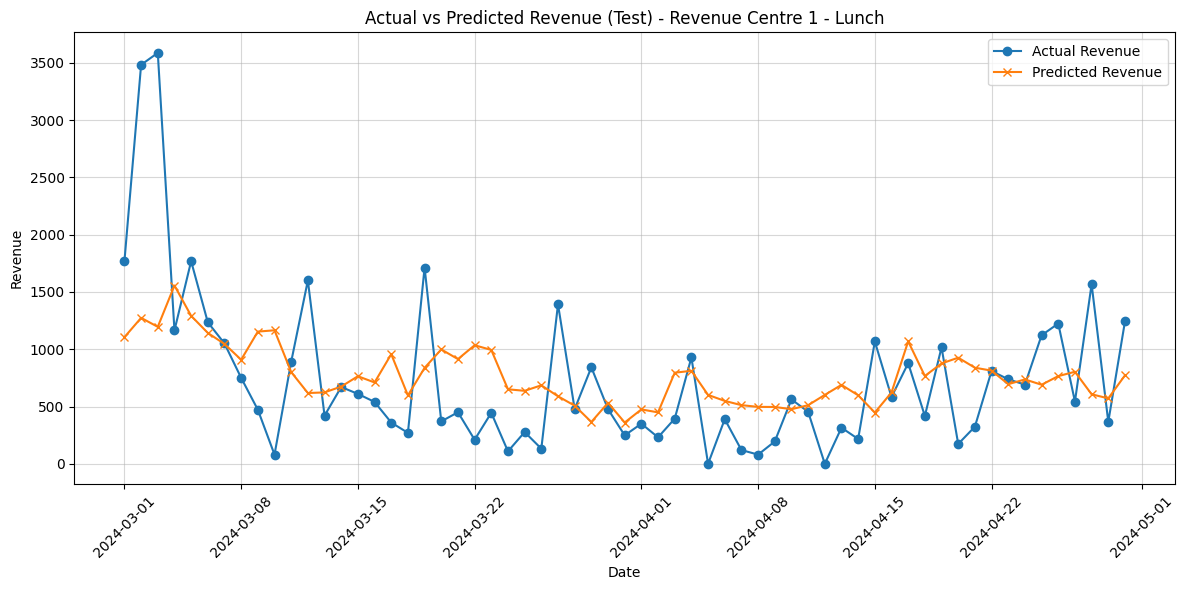

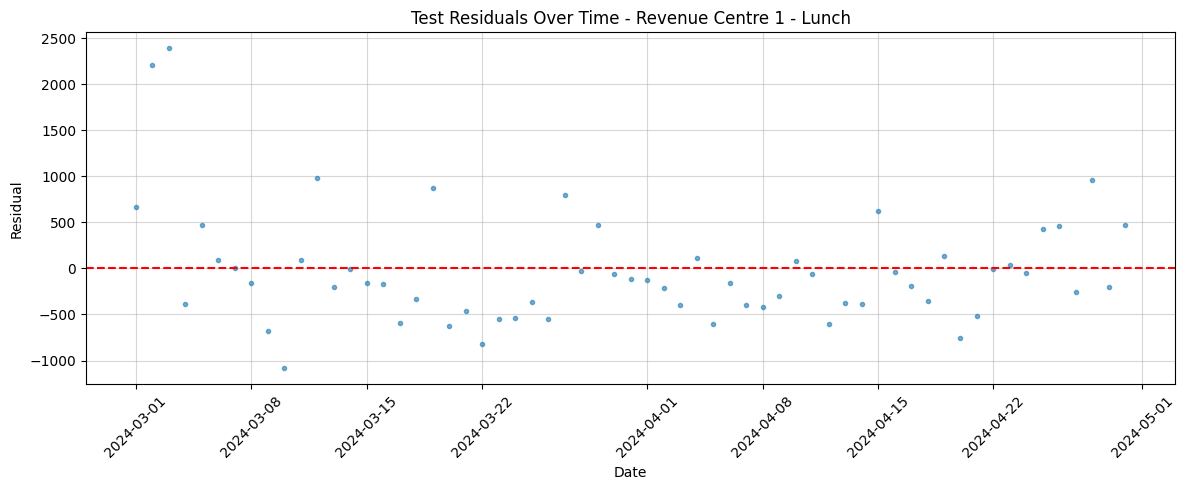

📄 Saved summary: github_results/Revenue_Centre_1_summary.csv
             Center Meal_Period  Best_LR  Best_Units  Best_Alpha    CV_RMSE  \
0  Revenue Centre 1   BreakFast   0.0100          64        10.0   954.2895   
1  Revenue Centre 1      Dinner   0.0005         128         1.0  1562.3572   
2  Revenue Centre 1       Lunch   0.0020         128        10.0   789.7575   

   CV_W_LSTM  CV_W_Ridge  
0     0.4675      0.5325  
1     0.4443      0.5557  
2     0.4881      0.5119  

================= Revenue Centre 2 =================
✅ Optimal Params for Revenue Centre 2 - BreakFast: LR=0.01, Units=64, Alpha=10.0 | CV RMSE=331.40, Weights(LSTM=0.54, Ridge=0.46)
📊 Training Final Model for Revenue Centre 2 - BreakFast (LR=0.01, Units=64, Alpha=10.0)


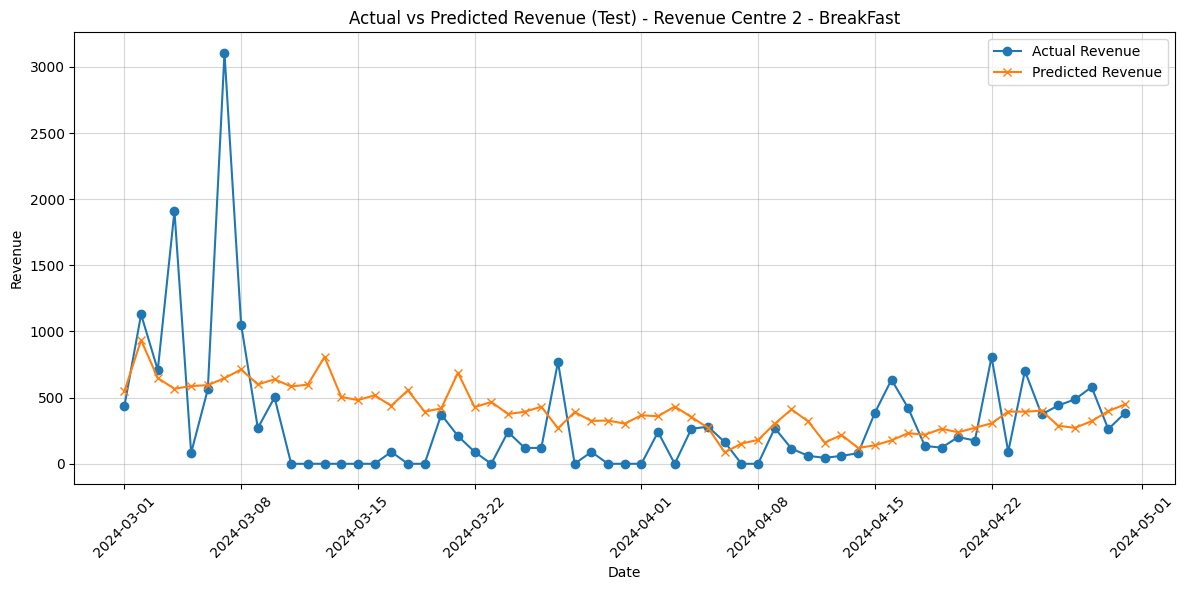

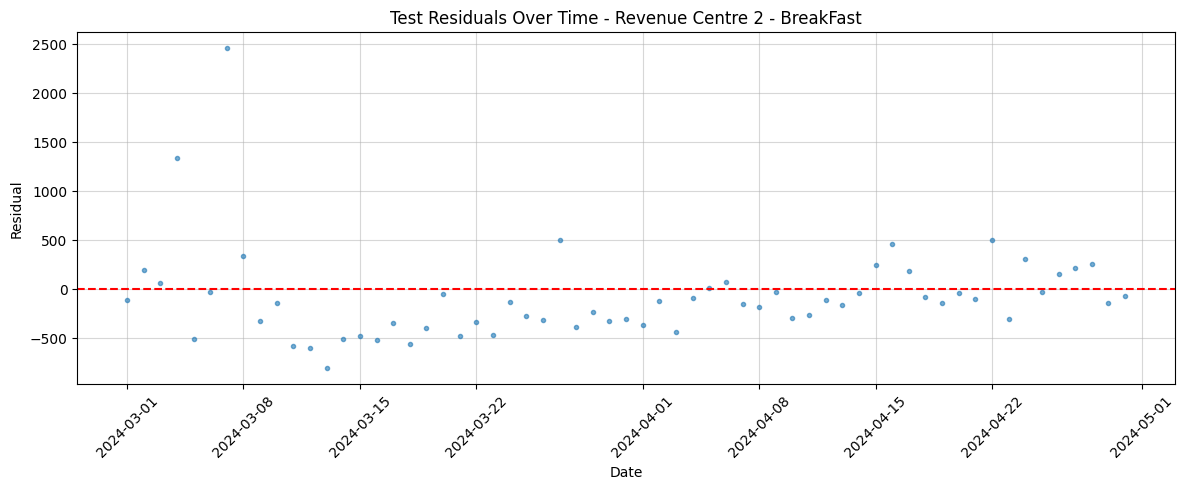

✅ Optimal Params for Revenue Centre 2 - Dinner: LR=0.0005, Units=128, Alpha=1.0 | CV RMSE=888.74, Weights(LSTM=0.51, Ridge=0.49)
📊 Training Final Model for Revenue Centre 2 - Dinner (LR=0.0005, Units=128, Alpha=1.0)


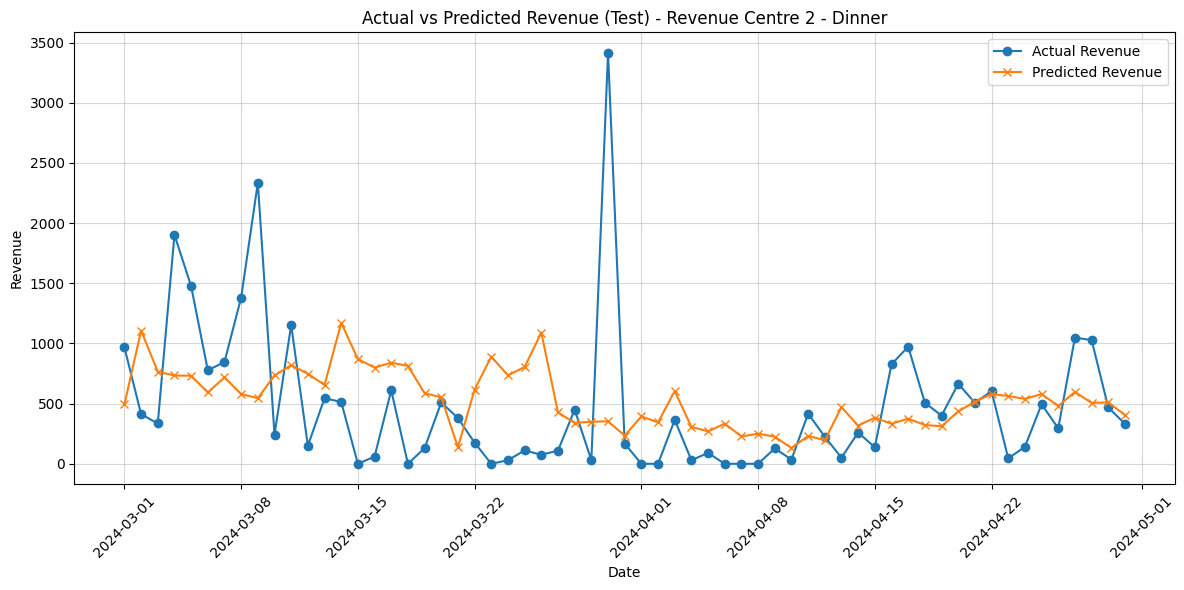

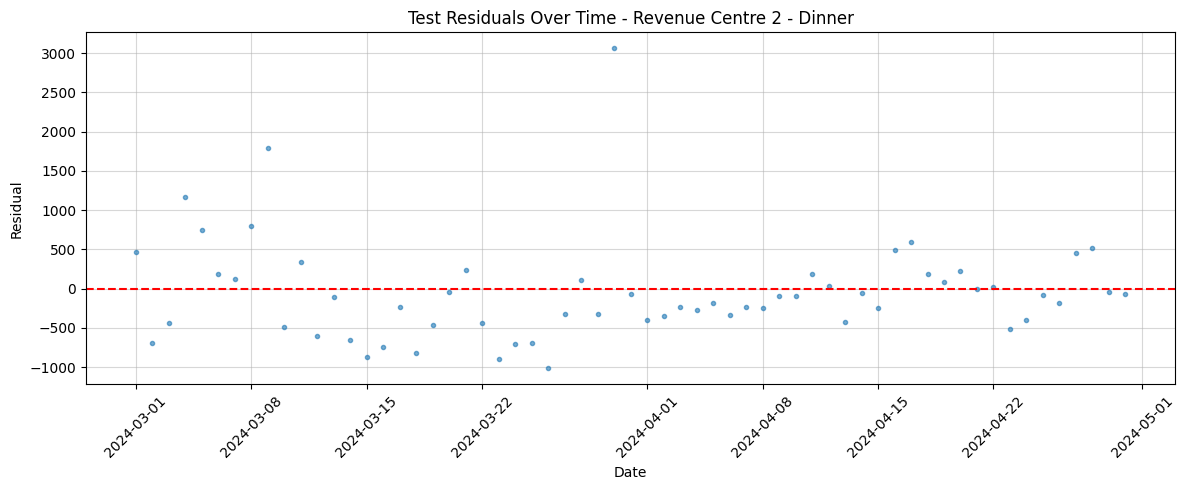

✅ Optimal Params for Revenue Centre 2 - Lunch: LR=0.001, Units=128, Alpha=10.0 | CV RMSE=415.92, Weights(LSTM=0.51, Ridge=0.49)
📊 Training Final Model for Revenue Centre 2 - Lunch (LR=0.001, Units=128, Alpha=10.0)


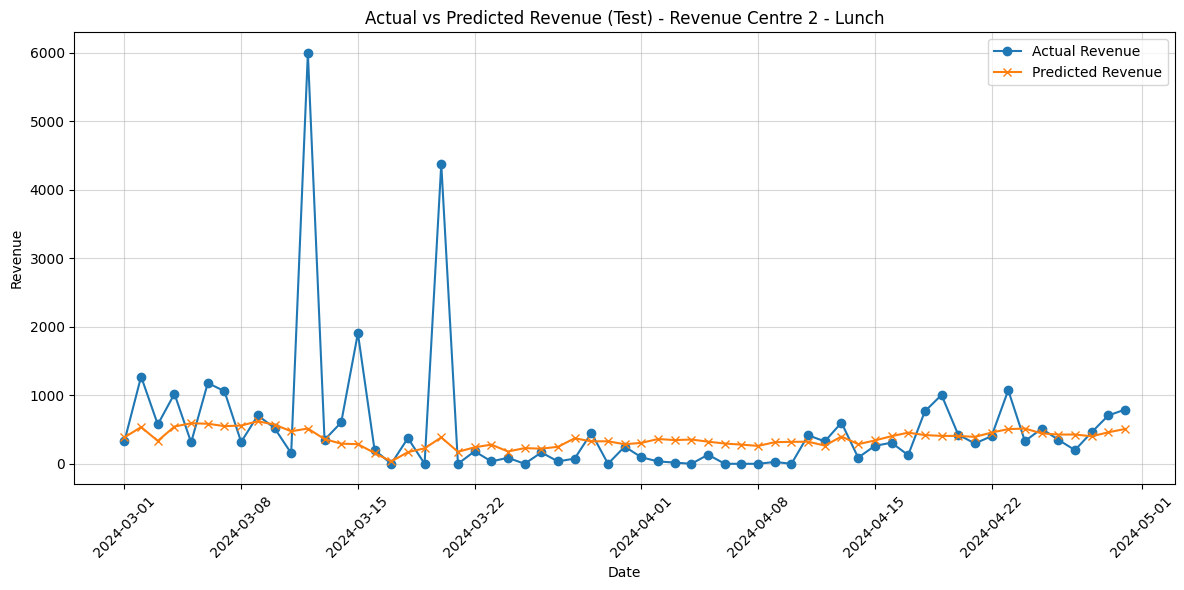

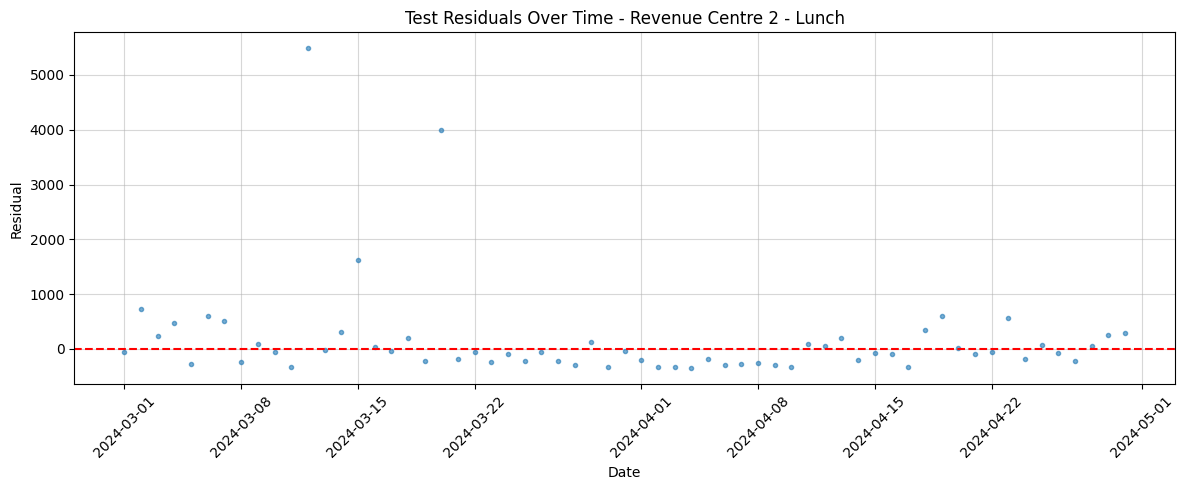

📄 Saved summary: github_results/Revenue_Centre_2_summary.csv
             Center Meal_Period  Best_LR  Best_Units  Best_Alpha   CV_RMSE  \
0  Revenue Centre 2   BreakFast   0.0100          64        10.0  331.3973   
1  Revenue Centre 2      Dinner   0.0005         128         1.0  888.7443   
2  Revenue Centre 2       Lunch   0.0010         128        10.0  415.9242   

   CV_W_LSTM  CV_W_Ridge  
0     0.5412      0.4588  
1     0.5085      0.4915  
2     0.5121      0.4879  


In [14]:
# ================== LOAD CENTERS AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    """Load one center's sheet from Excel and parse Date column."""
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df

if __name__ == '__main__':
    # Iterate through centers (adjust range as needed)
    for center_id in range(0, 2):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")